In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.metrics import f1_score , precision_score , accuracy_score , confusion_matrix , ConfusionMatrixDisplay, recall_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [4]:
df = pd.read_csv("shop_smart_ecommerce.csv")

In [5]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [7]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

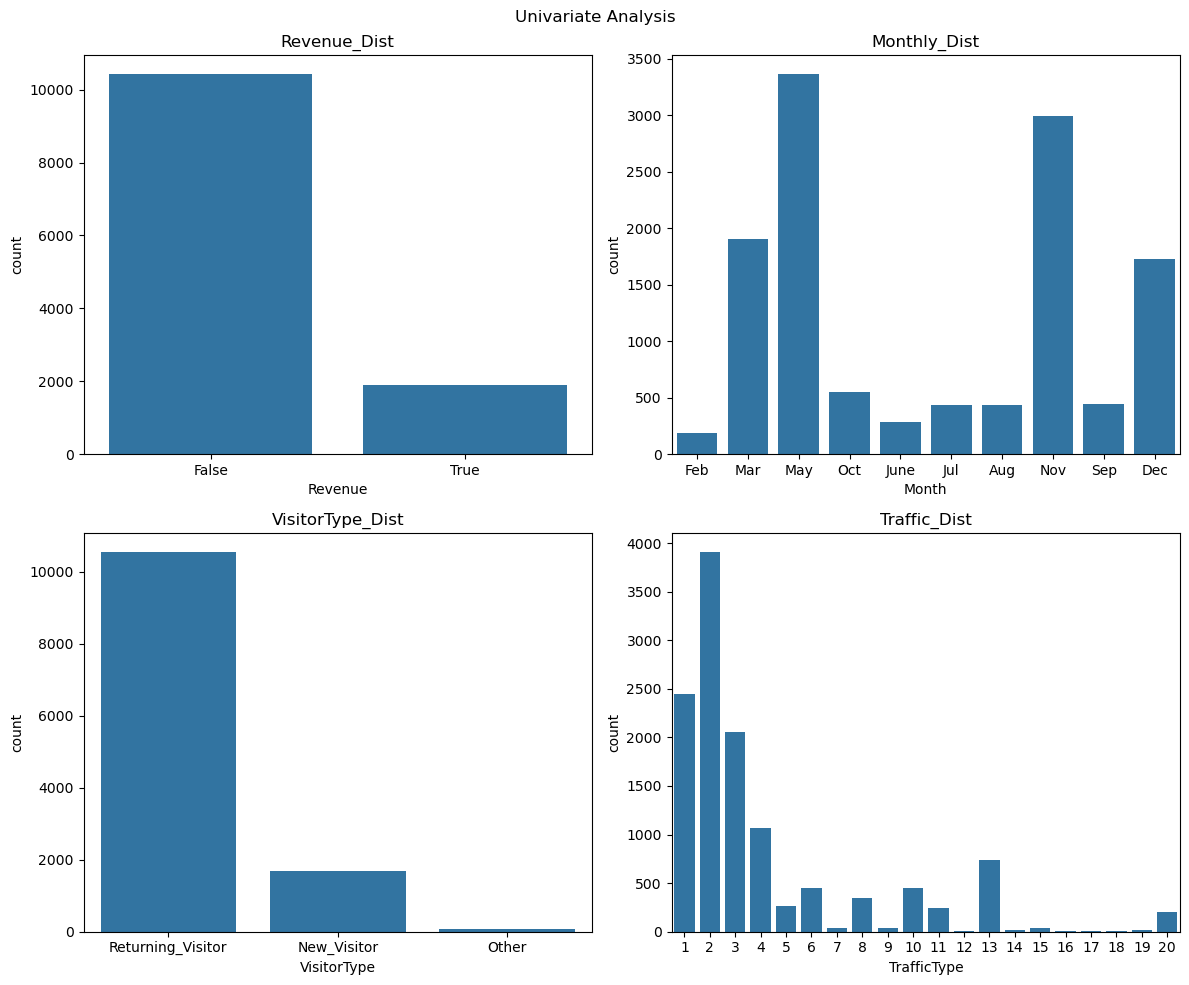

In [8]:
# EDA  - Univarite 

fig , ax = plt.subplots(2,2 , figsize = (12,10))

sns.countplot(x = "Revenue", data = df , ax = ax[0,0])
ax[0,0].set_title("Revenue_Dist")

sns.countplot(x = "Month" , data = df , ax = ax[0,1])
ax[0,1].set_title("Monthly_Dist")

sns.countplot(x = "VisitorType" , data = df , ax = ax[1,0])
ax[1,0].set_title("VisitorType_Dist")

sns.countplot(x = "TrafficType" , data = df , ax = ax[1,1])
ax[1,1].set_title("Traffic_Dist")


plt.suptitle("Univariate Analysis")
plt.tight_layout()
plt.savefig("Univariate.png")
plt.show()


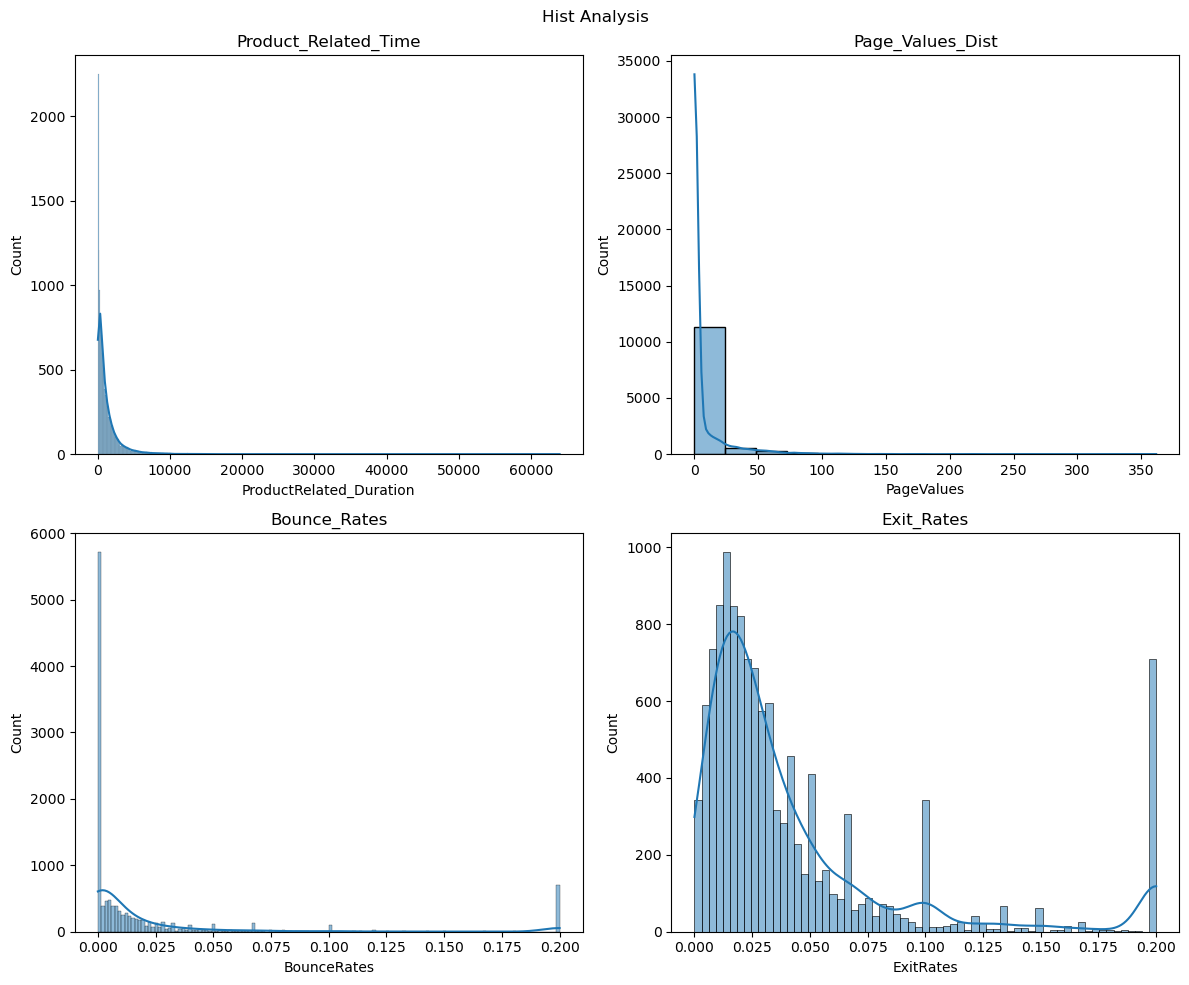

In [10]:
# Distribution plots 

fig , ax = plt.subplots(2,2 , figsize = (12,10))


sns.histplot(df["ProductRelated_Duration"], kde = True , ax = ax[0,0])
ax[0,0].set_title("Product_Related_Time")

sns.histplot(df["PageValues"], kde = True , ax = ax[0,1])
ax[0,1].set_title("Page_Values_Dist")

sns.histplot(df["BounceRates"], kde = True , ax = ax[1,0])
ax[1,0].set_title("Bounce_Rates")

sns.histplot(df["ExitRates"], kde = True , ax = ax[1,1])
ax[1,1].set_title("Exit_Rates")

plt.suptitle("Hist Analysis")
plt.tight_layout()
plt.savefig("Hist_Analysis")
plt.show()

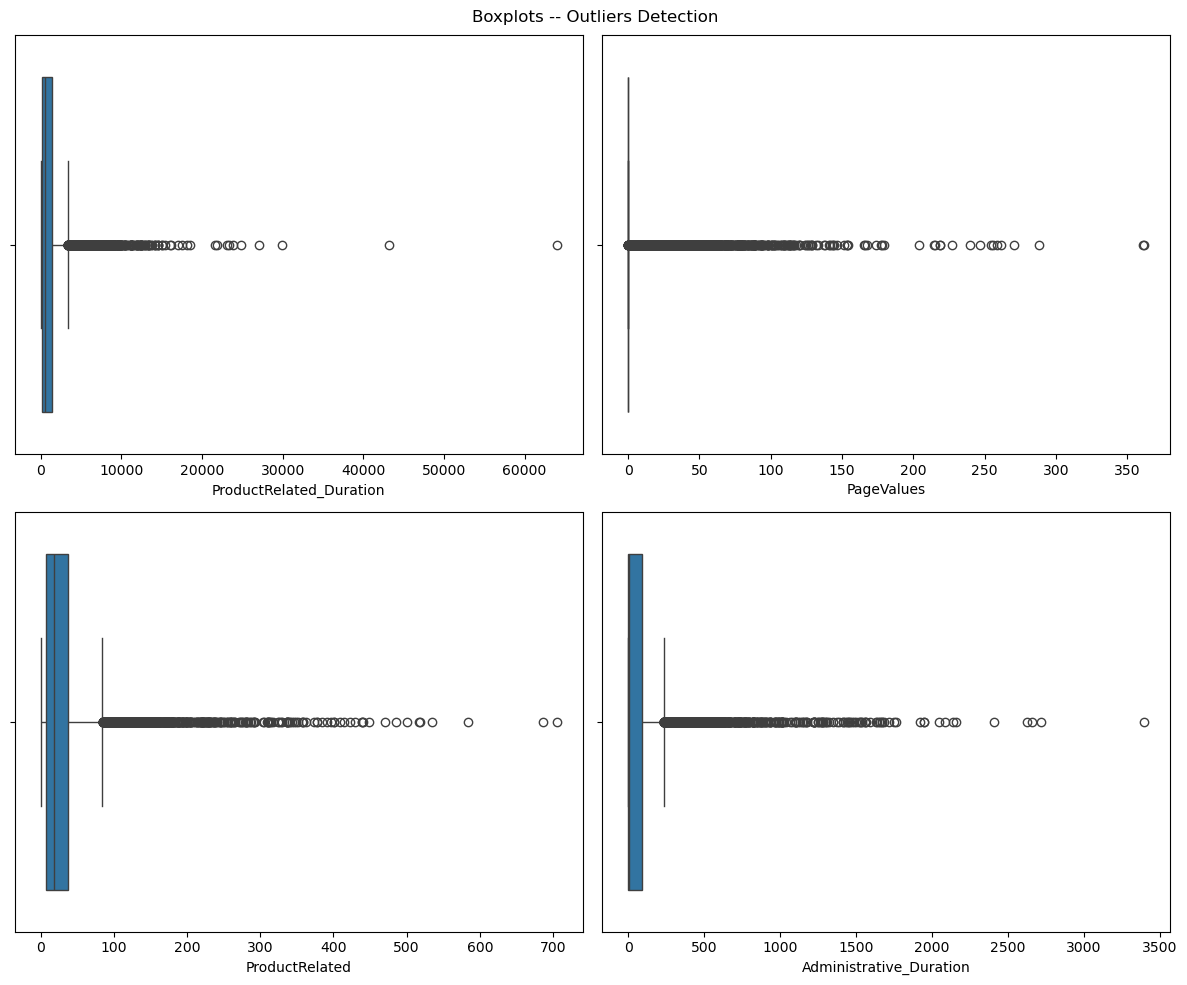

<Figure size 640x480 with 0 Axes>

In [11]:
# Boxplots -- Outlier Detection

fig , ax = plt.subplots(2,2 , figsize = (12,10))
sns.boxplot(x=df["ProductRelated_Duration"] , ax = ax[0,0])

sns.boxplot(x=df["PageValues"] , ax = ax[0,1])

sns.boxplot(x=df["ProductRelated"] , ax = ax[1,0])

sns.boxplot(x=df["Administrative_Duration"] , ax = ax[1,1])

plt.suptitle("Boxplots -- Outliers Detection")
plt.tight_layout()
plt.show()
plt.savefig("Boxplots")

# It shows that data is imbalanced 

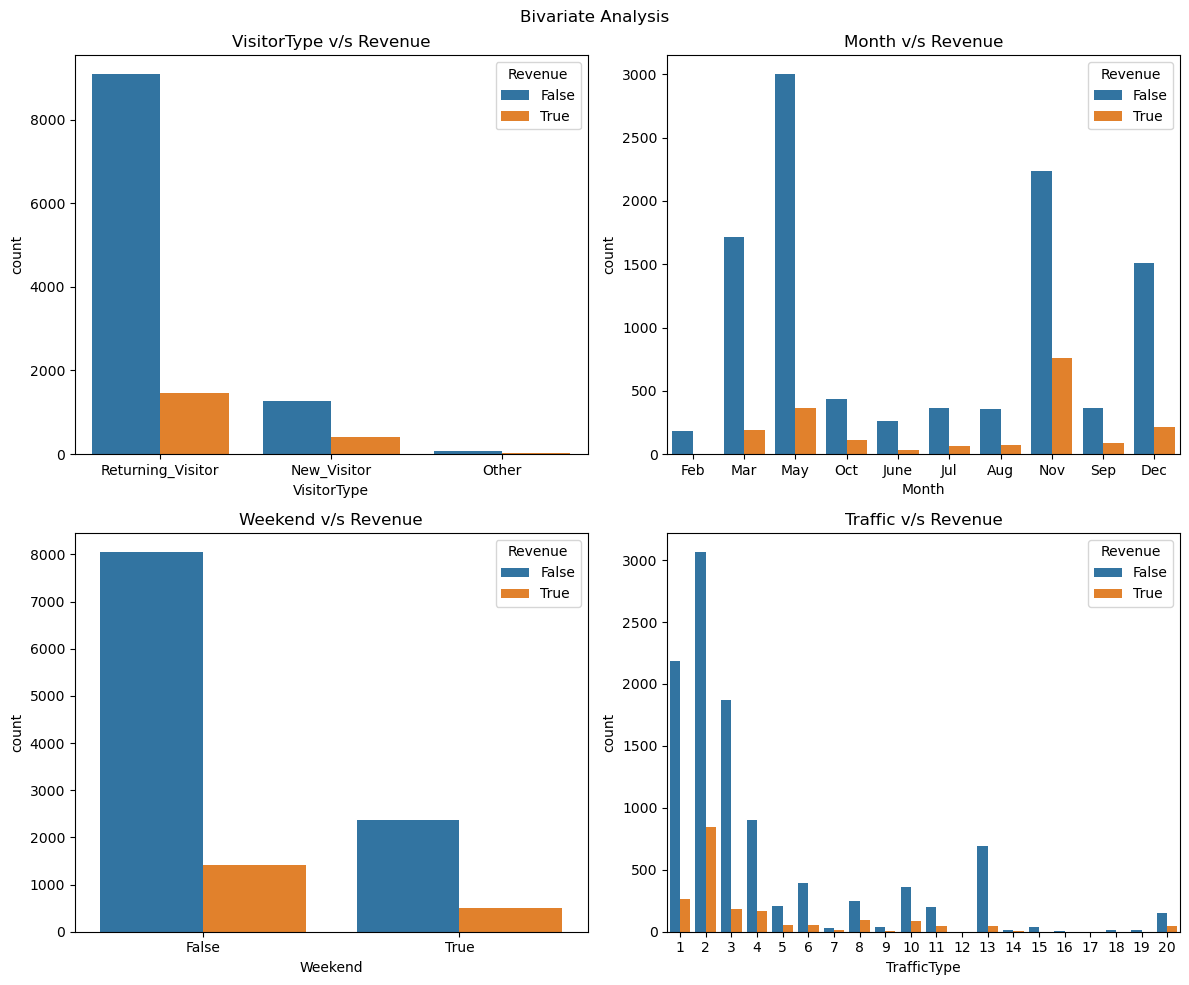

In [9]:
# Bivariate

fig , ax = plt.subplots(2,2 , figsize = (12,10))

sns.countplot(x = "VisitorType",hue = "Revenue", data = df , ax = ax[0,0])
ax[0,0].set_title("VisitorType v/s Revenue")

sns.countplot(x = "Month" , hue = "Revenue",data = df , ax = ax[0,1])
ax[0,1].set_title("Month v/s Revenue")

sns.countplot(x = "Weekend" , hue = "Revenue",data = df , ax = ax[1,0])
ax[1,0].set_title("Weekend v/s Revenue")

sns.countplot(x = "TrafficType" , hue = "Revenue", data = df , ax = ax[1,1])
ax[1,1].set_title("Traffic v/s Revenue")


plt.suptitle("Bivariate Analysis")
plt.tight_layout()
plt.show()

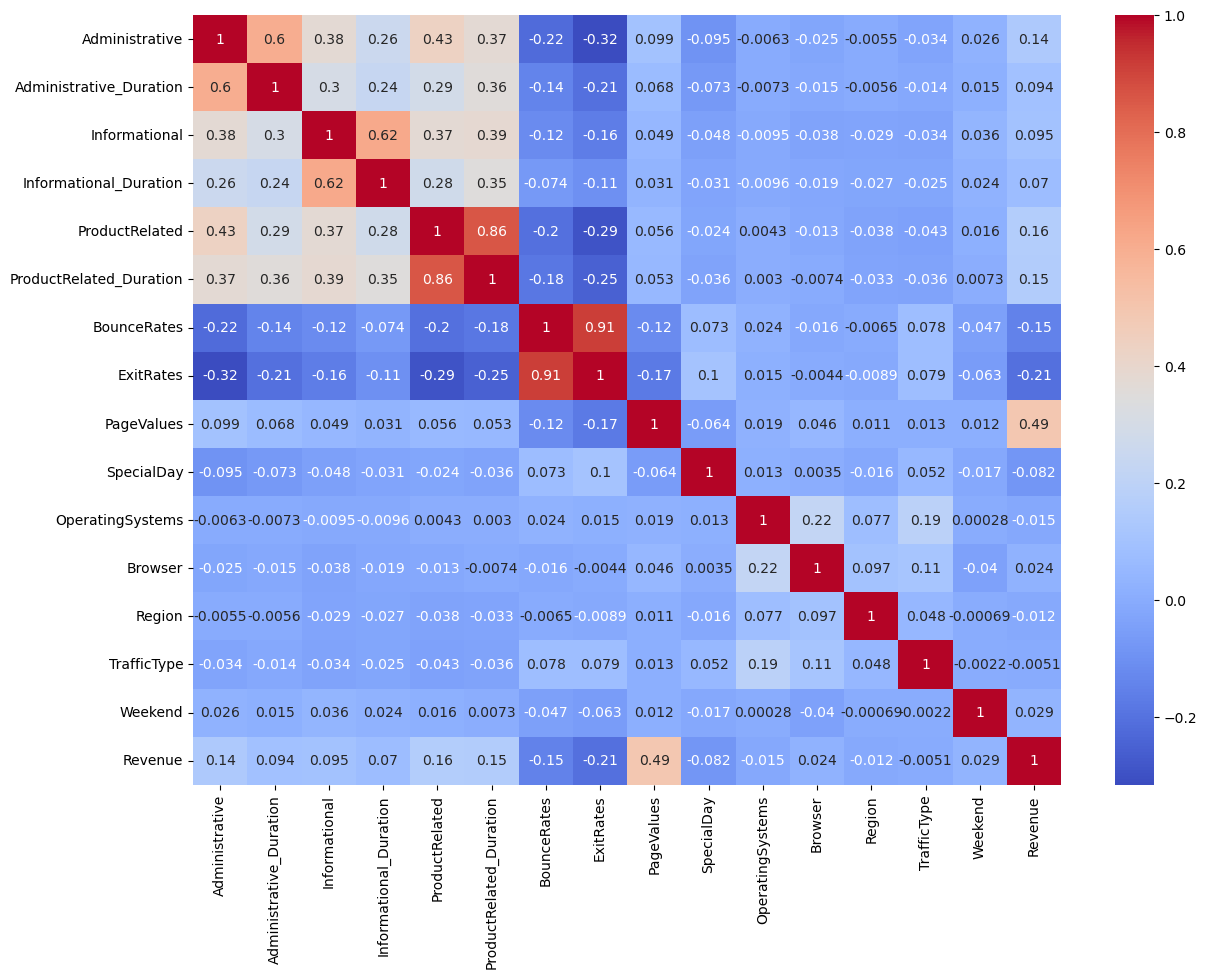

<Figure size 640x480 with 0 Axes>

In [12]:
# correlation Heatmap

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()
plt.savefig("Correlation Heatmap")

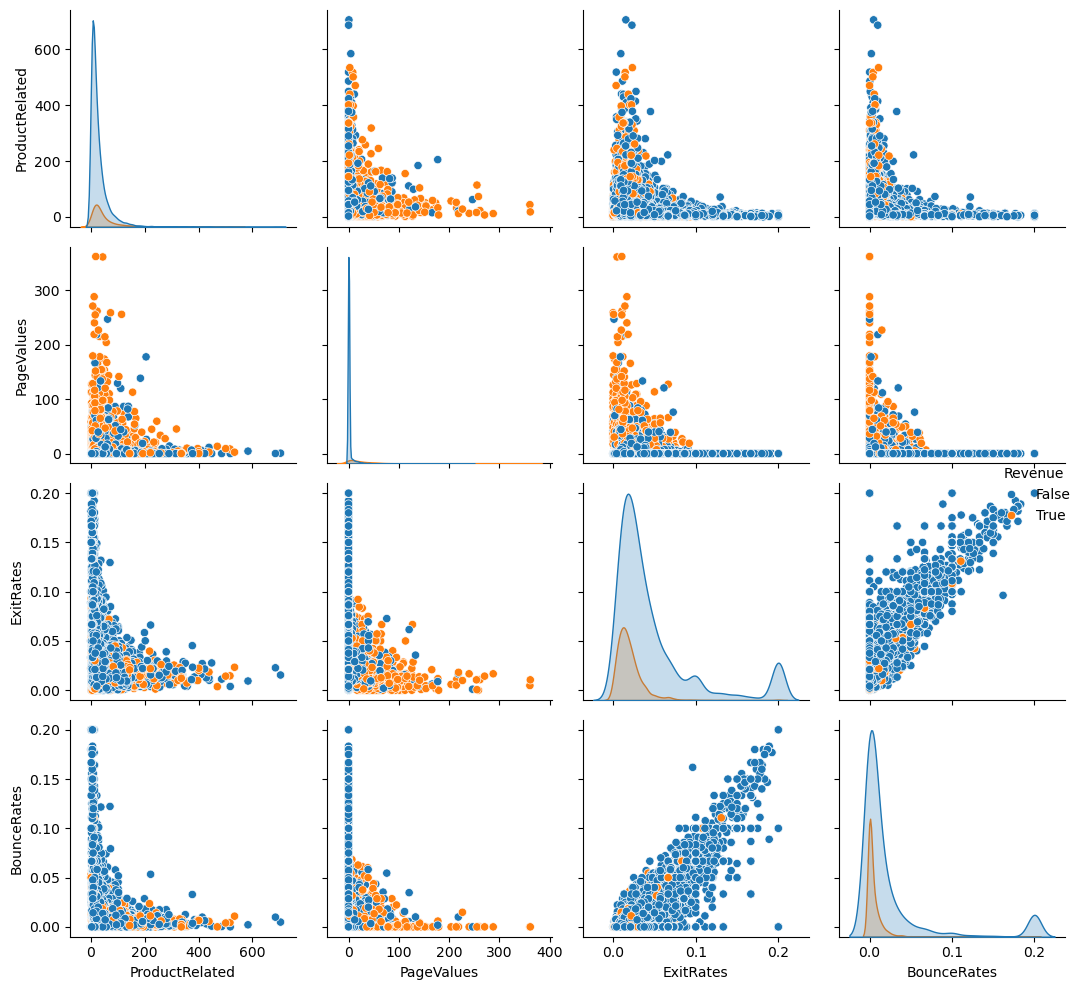

In [13]:
# pairplot

sns.pairplot(
    df[
        [
            "ProductRelated",
            "PageValues",
            "ExitRates",
            "BounceRates",
            "Revenue"
        ]
    ],
    hue="Revenue"
)
plt.tight_layout()
plt.savefig("Pairplot")

In [12]:
# Feature Engineering 
df["Total_Duration"] = (df["Administrative_Duration"]+df["Informational_Duration"]+df["ProductRelated_Duration"])
df["Total_Pages"] = (df["Administrative"] + df["Informational"] + df["ProductRelated"])
df["Avg_Pro_Page"] = (df["ProductRelated_Duration"]/(df["ProductRelated"] + 1))
df["Engagement"] = (df["Total_Pages"] * df["Total_Duration"])

In [13]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Total_Duration,Total_Pages,Avg_Pro_Page,Engagement
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,1,1,Returning_Visitor,False,False,0.000000,1,0.000000,0.000000
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,2,1,2,Returning_Visitor,False,False,64.000000,2,21.333333,128.000000
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,9,3,Returning_Visitor,False,False,0.000000,1,0.000000,0.000000
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,2,2,4,Returning_Visitor,False,False,2.666667,2,0.888889,5.333333
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,3,1,4,Returning_Visitor,True,False,627.500000,10,57.045455,6275.000000


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["VisitorType"] = le.fit_transform(df["VisitorType"])
df["Weekend"] = le.fit_transform(df["Weekend"])
df["Revenue"] = le.fit_transform(df["Revenue"])

In [15]:
X = df.drop(columns = ["Month","Revenue"])
y = df["Revenue"]

In [16]:
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Total_Duration,Total_Pages,Avg_Pro_Page,Engagement
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,1,1,1,1,2,0,0.000000,1,0.000000,0.000000
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,1,2,2,0,64.000000,2,21.333333,128.000000
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,4,1,9,3,2,0,0.000000,1,0.000000,0.000000
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,3,2,2,4,2,0,2.666667,2,0.888889,5.333333
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,3,3,1,4,2,1,627.500000,10,57.045455,6275.000000


In [17]:
X_train , X_test , y_train , y_test = train_test_split(
    X, y , test_size = 0.2 , random_state = 42)

In [18]:
X_train.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Total_Duration,Total_Pages,Avg_Pro_Page,Engagement
1785,0,0.0,0,0.0,7,95.000000,0.014286,0.061905,0.000000,0.0,2,6,1,1,2,0,95.000000,7,11.875000,665.000000
10407,2,14.0,0,0.0,81,1441.910588,0.002469,0.013933,2.769599,0.0,2,2,3,2,2,0,1455.910588,83,17.584275,120840.578804
286,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,2,2,1,1,2,0,0.000000,1,0.000000,0.000000
6520,5,49.2,4,379.0,5,74.600000,0.000000,0.018182,8.326728,0.0,2,2,8,2,0,0,502.800000,14,12.433333,7039.200000
12251,0,0.0,1,5.0,9,279.000000,0.040000,0.041667,0.000000,0.0,3,2,7,8,0,1,284.000000,10,27.900000,2840.000000


In [19]:
y_train.head()

1785     0
10407    0
286      0
6520     0
12251    0
Name: Revenue, dtype: int64

In [20]:
from sklearn.tree import DecisionTreeClassifier 

model = DecisionTreeClassifier()

model.fit(X_train,y_train)

DecisionTreeClassifier()

In [21]:
y_pred = model.predict(X_test)



print("f1_score :", f1_score(y_test,y_pred)*100,"%")
print("Accuracy_Score :", accuracy_score(y_test,y_pred)*100,"%")
print("Precison_Score :", precision_score(y_test,y_pred)*100,"%")

cm = confusion_matrix(y_test,y_pred)
print("Confusion_matrix :", confusion_matrix(y_test,y_pred))


f1_score : 55.44554455445545 %
Accuracy_Score : 85.40145985401459 %
Precison_Score : 56.42317380352645 %
Confusion_matrix : [[1882  173]
 [ 187  224]]


In [22]:
max_depth = [2,3,4,5,6,7,9,10]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)
    
    print(f"for depth = {depth}, f1_score = {f1_score(y_test,y_pred)}")

for depth = 2, f1_score = 0.5256609642301711
for depth = 3, f1_score = 0.6016042780748663
for depth = 4, f1_score = 0.580829756795422
for depth = 5, f1_score = 0.580829756795422
for depth = 6, f1_score = 0.5462822458270106
for depth = 7, f1_score = 0.5533834586466165
for depth = 9, f1_score = 0.5806451612903226
for depth = 10, f1_score = 0.5698005698005698


In [23]:
min_samples_split = [10,15,20,25]


for sample in min_samples_split:
    model = DecisionTreeClassifier(max_depth = 3 , min_samples_split = sample)
    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)
    print(f"for min_sampe = {sample}, f1_score = {f1_score(y_test,y_pred)}")

for min_sampe = 10, f1_score = 0.6016042780748663
for min_sampe = 15, f1_score = 0.6016042780748663
for min_sampe = 20, f1_score = 0.6016042780748663
for min_sampe = 25, f1_score = 0.6016042780748663


In [24]:
min_samples_leaf = [1,2,3,4,5,6,7,8,9,10]


for leaf in min_samples_leaf:
    model = DecisionTreeClassifier(max_depth = 3 , min_samples_split = 10, min_samples_leaf = leaf )
    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)
    print(f"for min_leaf = {leaf}, f1_score = {f1_score(y_test,y_pred)}")

for min_leaf = 1, f1_score = 0.6016042780748663
for min_leaf = 2, f1_score = 0.6016042780748663
for min_leaf = 3, f1_score = 0.6016042780748663
for min_leaf = 4, f1_score = 0.6016042780748663
for min_leaf = 5, f1_score = 0.6016042780748663
for min_leaf = 6, f1_score = 0.6016042780748663
for min_leaf = 7, f1_score = 0.6016042780748663
for min_leaf = 8, f1_score = 0.6016042780748663
for min_leaf = 9, f1_score = 0.6016042780748663
for min_leaf = 10, f1_score = 0.6016042780748663


In [25]:
pre_pruned_model = DecisionTreeClassifier(max_depth = 3)
pre_pruned_model.fit(X_train,y_train)

y_pred = pre_pruned_model.predict(X_test)
f1 = f1_score(y_test,y_pred)

print(f"F1_score = {f1}")

F1_score = 0.6016042780748663


In [26]:
# post pruning 
full_tree = DecisionTreeClassifier()
full_tree.fit(X_train,y_train)


DecisionTreeClassifier()

In [27]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 3.37609766e-05 4.91985115e-05 5.76932939e-05
 6.66203221e-05 6.72144833e-05 6.73668369e-05 6.74597410e-05
 7.86453341e-05 8.05152979e-05 8.11030008e-05 8.44822925e-05
 8.46193193e-05 8.64244083e-05 8.68960723e-05 8.68960723e-05
 8.68960723e-05 9.01144453e-05 9.01144453e-05 9.07973309e-05
 9.17236319e-05 9.21625009e-05 9.29305218e-05 9.42996024e-05
 9.46201676e-05 9.48381864e-05 9.48381864e-05 9.50425791e-05
 9.50425791e-05 9.51863629e-05 9.52345843e-05 9.54152951e-05
 9.54152951e-05 9.57465982e-05 9.57465982e-05 9.60178457e-05
 9.60430273e-05 9.60430273e-05 9.60430273e-05 9.63098135e-05
 9.65511914e-05 9.65511914e-05 9.65511914e-05 9.65511914e-05
 9.67706260e-05 9.71546364e-05 9.74795683e-05 9.74795683e-05
 9.76239825e-05 9.76239825e-05 9.77580813e-05 9.77580813e-05
 9.82594048e-05 9.82753199e-05 9.83066676e-05 9.83066676e-05
 9.83066676e-05 9.83066676e-05 9.85626746e-05 9.85626746e-05
 9.86387848e-05 9.86387848e-05 9.86387848e-05 9.87108891e-05
 9.88442822e-05 9.896497

In [28]:
# train model for all alphas 

trees = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state = 42 , ccp_alpha = alpha)
    model.fit(X_train,y_train)

    trees.append((model,alpha))

In [29]:
best_f1 = 0
best_alpha = 0 

for model,alpha in trees:
    y_pred = model.predict(X_test)
    curr_f1 = f1_score(y_test,y_pred)
    if curr_f1 > best_f1:
        best_f1 = curr_f1
        best_alpha = alpha

In [30]:
best_f1

0.6742502585315409

In [31]:
best_alpha

np.float64(0.01014735484966943)

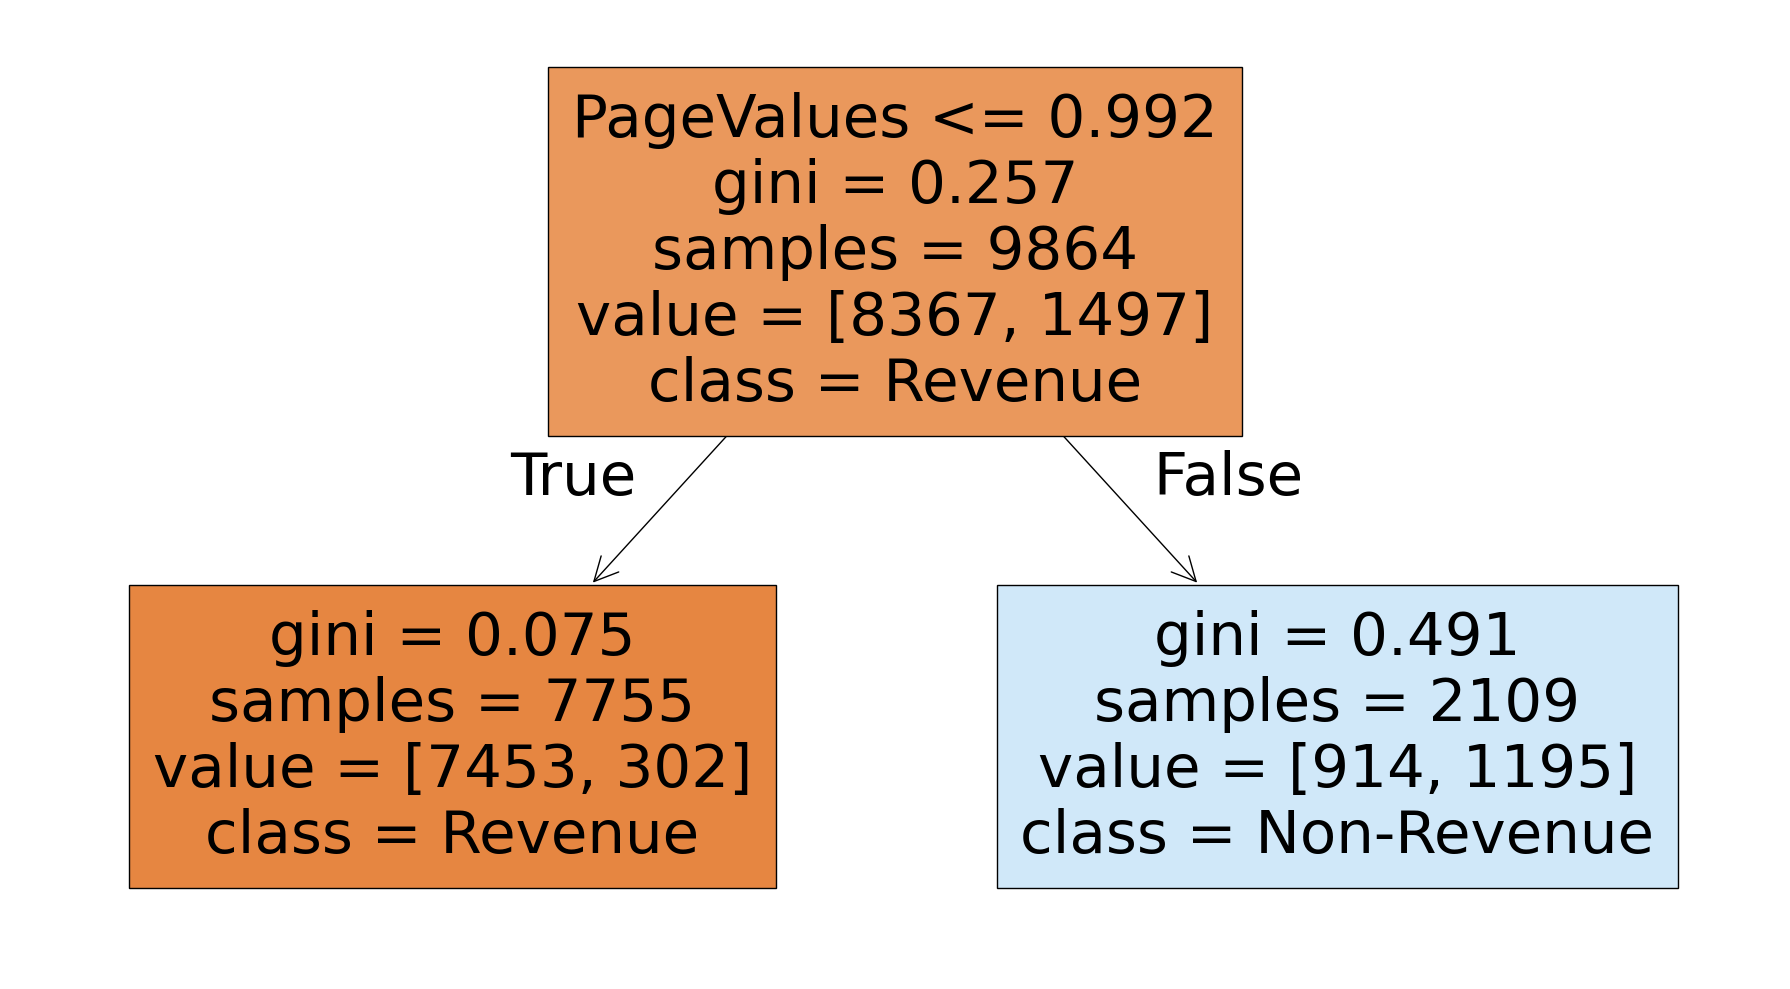

In [32]:
from sklearn.tree import plot_tree

best_model = DecisionTreeClassifier(ccp_alpha = best_alpha)
best_model.fit(X_train,y_train)

plt.figure(figsize = (18,10))

plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["Revenue","Non-Revenue"],
    filled = True
)
plt.tight_layout()
plt.show()

f1_score : 67.42502585315408 %
Accuracy_Score : 87.22627737226277 %
Precison_Score : 58.63309352517986 %
Recall_Score : 79.31873479318735 %
Confusion_matrix : [[1825  230]
 [  85  326]]


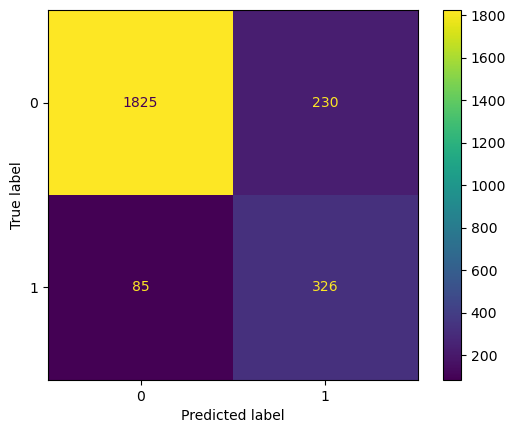

In [33]:
y_pred = best_model.predict(X_test)



print("f1_score :", f1_score(y_test,y_pred)*100,"%")
print("Accuracy_Score :", accuracy_score(y_test,y_pred)*100,"%")
print("Precison_Score :", precision_score(y_test,y_pred)*100,"%")
print("Recall_Score :", recall_score(y_test,y_pred)*100,"%")

cm = confusion_matrix(y_test,y_pred)
print("Confusion_matrix :", confusion_matrix(y_test,y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()

plt.show()

In [34]:
# Logistic Model --- Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
from sklearn.linear_model import LogisticRegression

Logistic_model = LogisticRegression(max_iter = 10000)

Logistic_model.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=10000)

f1_score : 46.05042016806723 %
Accuracy_Score : 86.98296836982968 %
Precison_Score : 74.45652173913044 %
Recall_Score : 33.33333333333333 %
Confusion_matrix : [[2008   47]
 [ 274  137]]


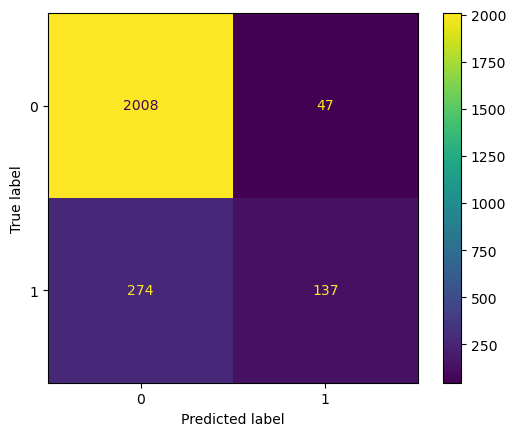

In [36]:
y_pred = Logistic_model.predict(X_test_scaled)



print("f1_score :", f1_score(y_test,y_pred)*100,"%")
print("Accuracy_Score :", accuracy_score(y_test,y_pred)*100,"%")
print("Precison_Score :", precision_score(y_test,y_pred)*100,"%")
print("Recall_Score :", recall_score(y_test,y_pred)*100,"%")

cm = confusion_matrix(y_test,y_pred)
print("Confusion_matrix :", confusion_matrix(y_test,y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()

plt.show()

In [37]:
# Random Forest 

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [38]:
rf_pred = rf_model.predict(X_test)

In [39]:
print("Accuracy :", accuracy_score(y_test, rf_pred)*100,"%")
print("Precision:", precision_score(y_test, rf_pred)*100,"%")
print("Recall   :", recall_score(y_test, rf_pred)*100,"%")
print("F1 Score :", f1_score(y_test, rf_pred)*100,"%")

Accuracy : 88.88888888888889 %
Precision: 76.24521072796935 %
Recall   : 48.41849148418492 %
F1 Score : 59.226190476190474 %
